# Problembeschreibung

Die Debatten im Bundestag sind oft hitzig und laut. Dass es ziemlich viele Zwischenrufe gibt, wurde schon in der statistischen Analyse klar, aber nicht alle Zwischenrufe sind negativ.
Oft gibt es auch Bekräftigung aus der eigenen Fraktion oder Koalition. 
Deswegen versuchen wir mit diesem Notebook die verschiedenen Arten von Zwischenrufen im Bundestag zu hinsichtlich ihres Sentiments zu analysieren. Insbesondere wollen wir untersuchen, wie oft Zwischenrufe positiver oder negativer Natur sind und welche Fraktionen am häufigsten beteiligt sind.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [4]:
non_string_entries = df_interruptions['comment_text'].apply(lambda x: not isinstance(x, str))
df_interruptions= df_interruptions[~non_string_entries]

# Einordnung in Taxonomie der Sentiment Analyse

![](./image_resources/sentiment_taxonomy.png )

Ich würde den hier im Notebook gelieferten Task als Opinion Polarity Classification einordnen. Allerdings haben unsere Daten die Besonderheit, dass viele der Zwischenrufe in herkömmlichen Kontexten als negativ gelten würden, einfach nur, weil sie dem Redner widersprechen. Der Bundestag ist aber ein Parlament und in einem Parlament wird nun einmal miteinander diskutiert. Deswegen ist der Grundton schon etwas kritischer. Uns interessieren deswegen im negativen Bereich eher die Aussagen, die den Redner, dessen Partei, oder dessen Politik klar angreifen. Dabei fallen dann Aussagen raus, die den Redner nur verbessern (aus Sicht des Unterbrechers).

# Labeling

Das Labeling für die Daten hat sich als schwerer als gedacht herausgestellt. Selbst wir - als waschechte Mitglieder der menschlichen Spezies - waren uns an vielen Stellen unsicher, ob eine Unterbrechung negatives, oder neutrales Sentiment enthält.  
Zu den Daten muss man sagen, dass  
    a) wie in der statistischen Analyse gezeigt, die meisten Unterbrechungen mit '!' enden, was jede Aussage in positive oder negative Richtung verstärkt und  
    b) die Abgeordneten eher selten etwas hineinrufen, wenn sie nicht noch eine Aussage des Redners korrigieren wollen. 
Diese Kombination macht es schwierig, den Daten einheitlich Labels zu geben.   
Hier ein paar Beispiele:
1. > Es war so eine schöne Rede!   

    Man könnte meinen, der Satz drückt die positive Einstellung des Unterbrechers/der Unterbrecherin aus, aber wenn man in den Kontext hineinschaut, sieht man direkt, dass das Gegenteil der Fall ist.
    Hier wollte Wolfgang Roth (SPD) darauf hinweisen, dass die Rede schön **war** und sie es jetzt aber nicht mehr ist, weil der Redner Helmut Haussmann (FDP) keine Ratschläge der Sozialdemokraten annehmen will und sagt, dass er/seine Fraktion diese nicht braucht.  
    Das Sentiment, das in der Aussage enthalten ist, ist also negativ.  

2. > Sie sind immer wieder gut!

    Das hier ist ein Standard-Fall von Sarkasmus.  
    Der Abgeordnete Sebastian Münzenmaier (AfD) wollte der SPD-Abgeordneten Helge Lindh leider kein Kompliment zu ihrer Arbeit machen.

3. > Das ist doch positiv!  

    Hier widerspricht Eva-Maria Kors (CDU/CSU) ihrer Kollegin Hildegard Wester (SPD) in einer Aussage zum Mutterschutz.  
    (Anmerkung: Das Beispiel hat mich an die Beispiele zu den Grenzen von wörterbuch-basierten Ansätzen aus der Vorlesung erinnert)  

4. > Das ist eine freie Entscheidung!
5. > Wir werden Sie beim Wort nehmen!
6. > Vier Tage Anhörung!

    Auch als Mensch kann man bei Beispielen 4-6 ohne Kontext nur raten. Außerdem ist selbst mit Kontext fragwürdig, ob ein `Wir werden Sie beim Wort nehmen!` einfach nur eine Herausforderung an die Redner-Partei ist, oder ob der Satz wirklich negatives Sentiment enthält.
    Diese Kontext-Abhängigkeien und die generell kritische Grundstimmung in Diskussionen führen dazu, dass die Unterscheidung zwischen den Labels schwierig ist.  
    

### Unsere Konventionen

Wir haben uns in der Gruppe dafür geeinigt, dass wir bei reinem Widerspruch, ohne persönlichen Angriff auf den Redner oder die Partei, das Label 'neutral' vergeben.  
Auch Sarkasmus, der ohne Kontext nicht ersichtlich ist, erhält das Label neutral (anders bei klar überzogenen Aussagen).
Das hat mehrere Gründe.
1. Die spätere Klassifikation durch das Modell soll aus Gründen der Performanz nur auf dem Text des Zwischenrufs basieren und nicht den Kontext miteinbeziehen.  
2. Uns sind vor allem die Unterbrechungen wichtig, bei denen der Unterbrecher relativ klar aufgebracht oder zustimmend ist. Dadurch, dass wir lieber etwas mehr fragwürdige Labels auf neutral setzen, liefert das Modell am Ende auch zuverlässigere Ergebnisse (höhere precision) auf den anderen beiden Kategorien. So zumindest der Gedankengang.

In [6]:
df_labeled  = pd.read_csv('./data/comments_for_labeling_robin_labeled_labeled_labeled.csv')
df_labeled.head()

,Unnamed: 0,comment_text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_id,preceding_context,sentiment
0,389767,Weiß das das Jugendamt?,SPD,Dr. Fritz Felgentreu,CDU/CSU,Dr. Heribert Hirte,2021-06-24,178843,"det, dann muss man auch sagen – wie viele Stun...",1
1,315825,Wieso?,CDU/CSU,Sylvia Pantel,SPD,Josip Juratovic,2016-12-16,142078,"eben. Ich habe immer gedacht, das ist unser La...",0
2,444172,Erasmus,AfD,Stephan Brandner,CDU/CSU,Philipp Amthor,2023-11-10,197933,ublik die parteinahen Stiftungen gegründet wur...,0
3,74996,Sehr richtig!,CDU/CSU,Steffen Kampeter,FDP,Cornelia Pieper,1999-11-25,45664,es Täuschungsmanöver war leicht zu durchschaue...,2
4,144703,Sie aber auch nicht!,GRÜNE,Hans-Christian Ströbele,CDU/CSU,Peter Rzepka,2004-10-21,68341,rag hier in diesem Hause ist; denn sie hat hie...,1


In [7]:
print(len(df_labeled))

1000


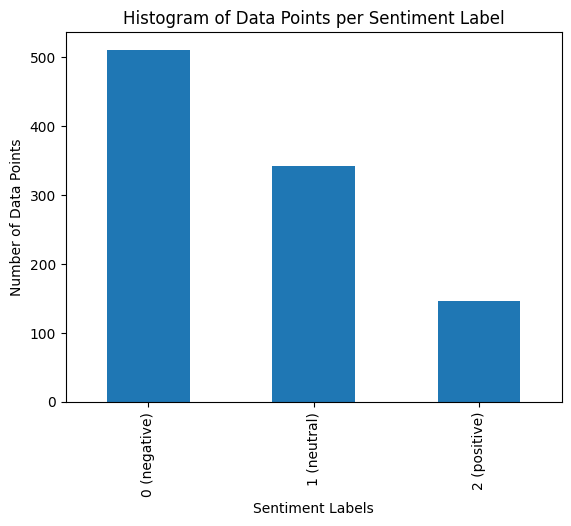

In [8]:
label_counts = df_labeled['sentiment'].value_counts()

sentiment_mapping = {0: 'negative', 1: 'neutral', 2: 'positive'}

ax = label_counts.plot(kind='bar')
ax.set_xlabel('Sentiment Labels')
ax.set_ylabel('Number of Data Points')
ax.set_title('Histogram of Data Points per Sentiment Label')

ax.set_xticklabels([f'{index} ({sentiment_mapping[index]})' for index in label_counts.index])

plt.show()

Zur Einstufung haben wir die Analyse erst einmal mit einem vorgefertigten Modell von Huggingface (ausgeliefert in einem eigenen Pip-Modul) getestet.

In [9]:
from germansentiment import SentimentModel

model = SentimentModel()

texts = [
    "Mit keinem guten Ergebniss","Das ist gar nicht mal so gut",
    "Total awesome!","nicht so schlecht wie erwartet",
    "Der Test verlief positiv.","Sie fährt ein grünes Auto."]
       
result = model.predict_sentiment(texts)
print(result)

['negative', 'negative', 'positive', 'positive', 'neutral', 'neutral']


c:\ProgFiles\PythonVenvs\.NLPvenv\Lib\site-packages\transformers\models\bert\modeling_bert.py:435: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at ..\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:263.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


In [10]:
preds = model.predict_sentiment(df_labeled['comment_text'])
senti_to_int= {'neutral': 0, 'negative':1, 'positive':2}

df_labeled['result'] = [senti_to_int[s] for s in preds]

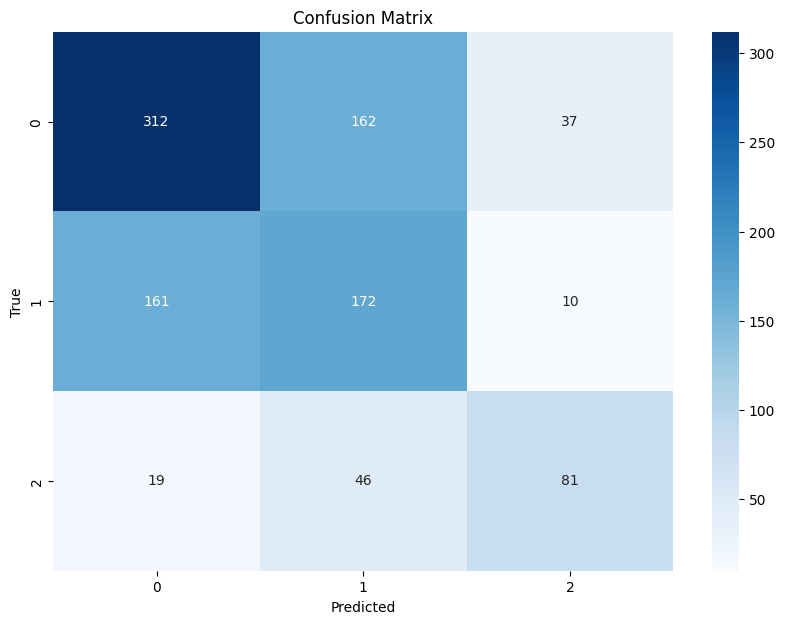

In [13]:
conf_matrix_bert = confusion_matrix(df_labeled['sentiment'], df_labeled['result'])
# plot confusion matrix
plt.figure(figsize=(10,7))
sns.heatmap(conf_matrix_bert, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

Man sieht hier, dass nicht nur wir uns schwer damit tun, in unseren Daten zwischen neutral und negativ zu unterscheiden. Der kritische Grundton im Parlament ist wohl für das Modell auch eine Neuheit.

In [15]:
from sklearn.metrics import classification_report
print(classification_report(df_labeled['sentiment'], df_labeled['result'], target_names=['neutral', 'negative', 'positive']))

              precision    recall  f1-score   support

     neutral       0.63      0.61      0.62       511
    negative       0.45      0.50      0.48       343
    positive       0.63      0.55      0.59       146

    accuracy                           0.56      1000
   macro avg       0.57      0.56      0.56      1000
weighted avg       0.57      0.56      0.57      1000



Auch die klassischen Evaluationsscores sind für die Standard-Variante ziemlich miserabel